# Atmosphere & chemistry — Sentinel-5P NO2

Tropospheric NO2 column density from TROPOMI on Sentinel-5P (near-real-time, ~7 km native pixel). A short window over Paris, reduced to one composite scene.

## Setup

The notebook reads the GEE service-account credentials from `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` environment variables. Both must be set before running this cell.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset as PyramidsDataset

from earthlens.gee import GEE, Catalog

OUT_DIR = Path('out') / 'atmosphere-chemistry'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SERVICE_ACCOUNT = os.environ['GEE_SERVICE_ACCOUNT']
SERVICE_KEY = os.environ['GEE_SERVICE_KEY']
print(f'output directory: {OUT_DIR.resolve()}')

2026-05-18 00:12:21 | INFO | pyramids.base.config | Logging is configured.


output directory: C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\gee\out\atmosphere-chemistry


## Inspect the catalog entry

Before downloading anything, look at what the bundled catalog knows about the asset — bands, cadence, license, provider.

In [2]:
cat = Catalog()
ds = cat.get_dataset('COPERNICUS/S5P/NRTI/L3_NO2')
print(f'title:               {ds.title}')
print(f'ee_type:             {ds.ee_type}')
print(f'spatial_resolution:  {ds.spatial_resolution} m')
print(f'extent.start_date:   {ds.extent.start_date}')
print(f'extent.end_date:     {ds.extent.end_date}')
print(f'default_reducer:     {ds.default_reducer}')
print(f'license:             {ds.license}')
print(f'provider:            {ds.provider}')
print(f'#bands:              {len(ds.bands)}')
print(f'band ids (first 5):  {list(ds.bands)[:5]}')

title:               Sentinel-5P NRTI NO2: Near-Real-Time Tropospheric Nitrogen Dioxide
ee_type:             image_collection
spatial_resolution:  1113.2 m
extent.start_date:   2018-07-10
extent.end_date:     None
default_reducer:     mean
license:             proprietary
provider:            copernicus
#bands:              4
band ids (first 5):  ['NO2_column_number_density', 'tropospheric_NO2_column_number_density', 'stratospheric_NO2_column_number_density', 'cloud_fraction']


## Download

Tiny AOI ([48.5, 49.5] lat, [2.0, 3.0] lon) at 7000.0 m, `raw` cadence — keeps the synchronous download under EE's 32768-px per-axis cap.

In [3]:
try:
    gee = GEE(
        start='2024-01-05',
        end='2024-01-10',
        variables={'COPERNICUS/S5P/NRTI/L3_NO2': ['tropospheric_NO2_column_number_density']},
        lat_lim=[48.5, 49.5],
        lon_lim=[2.0, 3.0],
        temporal_resolution='raw',
        path=str(OUT_DIR),
        service_account=SERVICE_ACCOUNT,
        service_key=SERVICE_KEY,
        scale=7000.0,
        reducer='mean',
    )
    paths = gee.download(progress_bar=False)
    print(f'wrote {len(paths)} GeoTIFF(s):')
    for p in paths:
        print(f'  {p}  ({p.stat().st_size / 1024:.1f} KB)')
    download_ok = True
except Exception as exc:
    if False:
        print(f'live EE call failed (tolerated for this category): {type(exc).__name__}: {exc}')
        paths = []
        download_ok = False
    else:
        raise

2026-05-18 00:12:29.235 | INFO     | earthlens.gee.backend:_download_one_url_tile:757 - Wrote C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\gee\out\atmosphere-chemistry\COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105.tif (3473 bytes)


wrote 1 GeoTIFF(s):
  C:\gdrive\algorithms\remote-sensing\earthlens\docs\examples\gee\out\atmosphere-chemistry\COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105.tif  (2.6 KB)


## Quick preview

Load the first written GeoTIFF through pyramids and render the single band. (`pyramids.dataset.Dataset` is the project's GeoTIFF/NetCDF wrapper.)

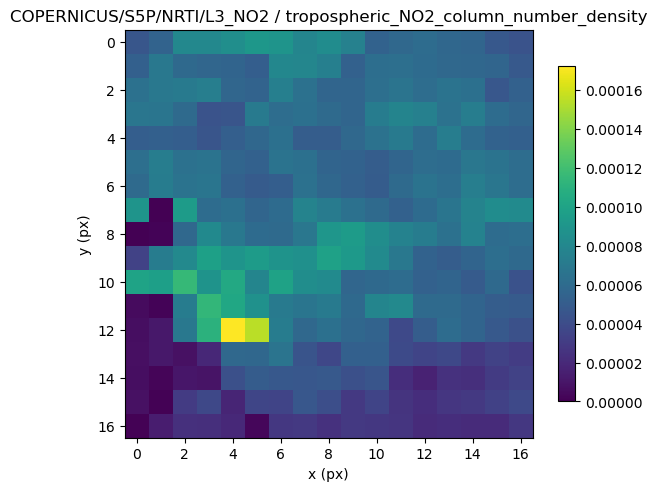

value range: [0, 0.0001723]


In [4]:
if not download_ok or not paths:
    print('Skipping preview — no GeoTIFF was written.')
else:
    pds = PyramidsDataset.read_file(str(paths[0]))
    arr = pds.read_array()
    if arr.ndim == 3:
        arr = arr[0]
    # Mask the dataset's nodata so the colormap doesn't get pinned to it.
    nodata = pds.no_data_value
    if nodata is not None:
        try:
            arr = np.ma.masked_equal(arr, float(nodata[0] if isinstance(nodata, (list, tuple)) else nodata))
        except (TypeError, ValueError):
            pass
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(arr, cmap='viridis')
    ax.set_title(f'{'COPERNICUS/S5P/NRTI/L3_NO2'} / {'tropospheric_NO2_column_number_density'}')
    ax.set_xlabel('x (px)')
    ax.set_ylabel('y (px)')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
    print(f'value range: [{float(np.nanmin(arr)):.4g}, {float(np.nanmax(arr)):.4g}]')

## Tracking submitted jobs (asynchronous export)

The download above uses `export_via="url"` — a synchronous `getDownloadURL` round-trip. Nothing was queued, so there's no Earth Engine job to track.

To track an export instead, switch to an asynchronous sink (`drive` / `gcs` / `asset`) and pass `wait_for_export=False` so `.download()` returns a `TaskInfo` at submission time rather than blocking until completion. The cells below submit the same `(asset_id, band, AOI, scale)` request as an `export_via="asset"` task into the service account's own asset folder, then walk the four jobs-API calls (`list_recent_tasks` → `wait_for_task_id` → `ee.data.getAsset` → `ee.data.deleteAsset`) to make the job finish *and* tidy up. See `track-batch-exports.ipynb` for a deeper worked example.

In [5]:
import ee
from earthlens.gee import list_recent_tasks, wait_for_task_id, cancel_task

# The asset goes into a `Folder` asset that we own. `GEE._export_via_batch`
# writes the actual image at `<asset_id>/<prefix>`, so `asset_id` here is
# the parent FOLDER (not the final image path). Both must be cleaned up.
_proj = ee.data._get_projects_path().removeprefix('projects/')
DEMO_FOLDER = f'projects/{_proj}/assets/earthlens-demo-atmosphere-chemistry'
print(f'demo folder: {DEMO_FOLDER}')

# Best-effort cleanup of leftover children from a previous run (so the
# folder is empty before we try to delete it below).
try:
    for child in ee.data.listAssets({'parent': DEMO_FOLDER}).get('assets', []):
        ee.data.deleteAsset(child['name'])
        print(f'cleared leftover child: {child["name"]}')
    ee.data.deleteAsset(DEMO_FOLDER)
    print(f'cleared leftover folder: {DEMO_FOLDER}')
except Exception:
    pass
# Create the parent folder — EE requires it to exist before a child write.
ee.data.createAsset({'type': 'Folder'}, DEMO_FOLDER)
print(f'created folder: {DEMO_FOLDER}')

demo folder: projects/earth-engine-415620/assets/earthlens-demo-atmosphere-chemistry


created folder: projects/earth-engine-415620/assets/earthlens-demo-atmosphere-chemistry


### Submit

Same `(asset_id, band, AOI, scale)` request as the sync download above, just routed through `export_via="asset"` + `wait_for_export=False`. `download()` returns a `TaskInfo` per submitted bucket at the moment the task is queued — no blocking.

In [6]:
submitted_ok = False
task_info = None
try:
    async_gee = GEE(
        start='2024-01-05',
        end='2024-01-10',
        variables={'COPERNICUS/S5P/NRTI/L3_NO2': ['tropospheric_NO2_column_number_density']},
        lat_lim=[48.5, 49.5],
        lon_lim=[2.0, 3.0],
        temporal_resolution='raw',
        path=str(OUT_DIR),
        service_account=SERVICE_ACCOUNT,
        service_key=SERVICE_KEY,
        scale=7000.0,
        reducer='mean',
        export_via='asset',
        asset_id=DEMO_FOLDER,
        wait_for_export=False,
    )
    submitted = async_gee.download(progress_bar=False)
    task_info = submitted[0]
    submitted_ok = True
    print(f'submitted: id={task_info.id} state={task_info.state}')
    print(f'           description={task_info.description}')
except Exception as exc:
    if False:
        print(f'async submission failed (tolerated): {type(exc).__name__}: {exc}')
    else:
        raise

2026-05-18 00:12:33.016 | INFO     | earthlens.gee.backend:_export_via_batch:833 - Submitted asset export ME3ZV7YPDTOFWHD5HFXTSRP2 (COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105); track via earthlens.gee.jobs.


submitted: id=ME3ZV7YPDTOFWHD5HFXTSRP2 state=READY
           description=COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105


### List + wait

`list_recent_tasks(description_prefix=...)` returns every matching task across the current project; `wait_for_task_id` blocks until the one we care about reaches a terminal state. A real workflow would just poll later from a separate process — the wait here exists so the notebook shows the full success path end-to-end.

In [7]:
if submitted_ok and task_info is not None:
    recent = list_recent_tasks(
        description_prefix=task_info.description,
        max_age_min=10,
    )
    print(f'list_recent_tasks matched {len(recent)} task(s):')
    for t in recent:
        print(f'  {t.id}  {t.state:<12} {t.description}')
    try:
        final = wait_for_task_id(
            task_info.id, poll_seconds=10, progress_bar=False,
        )
        print(f'\nfinal state: {final.state}')
    except RuntimeError as exc:
        # Raised on FAILED / CANCELLED — cancel-if-still-running
        # so we don't leak an in-flight task on notebook restart.
        print(f'wait_for_task_id raised: {exc}')
        try:
            cancel_task(task_info.id)
        except Exception:
            pass
else:
    print('Skipping list/wait — async submission did not succeed.')

list_recent_tasks matched 1 task(s):
  ME3ZV7YPDTOFWHD5HFXTSRP2  READY        COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105



final state: COMPLETED


### Verify + clean up

Confirm the produced asset exists on Earth Engine, then delete it (and the surrounding demo folder) so we don't leak storage between notebook runs. The backend wrote the image at `<DEMO_FOLDER>/<task description>`.

In [8]:
if submitted_ok and task_info is not None:
    produced = f'{DEMO_FOLDER}/{task_info.description}'
    try:
        meta = ee.data.getAsset(produced)
        print(f'asset exists: type={meta.get("type")} '
              f'name={meta.get("name")}')
        ee.data.deleteAsset(produced)
        print('asset deleted')
    except Exception as exc:
        print(f'verify/delete skipped: {exc}')
# Always try to tear down the parent folder.
try:
    ee.data.deleteAsset(DEMO_FOLDER)
    print(f'folder deleted: {DEMO_FOLDER}')
except Exception as exc:
    print(f'folder delete skipped: {exc}')

asset exists: type=IMAGE name=projects/earth-engine-415620/assets/earthlens-demo-atmosphere-chemistry/COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105


asset deleted


folder deleted: projects/earth-engine-415620/assets/earthlens-demo-atmosphere-chemistry


## What's on disk

The GeoTIFF (or empty list, if the EE call was tolerated) is left under the per-notebook `out/` directory for you to inspect. That directory is `.gitignore`d — re-running the notebook overwrites it.

In [9]:
for p in sorted(OUT_DIR.iterdir()) if OUT_DIR.exists() else []:
    print(f'{p}  ({p.stat().st_size / 1024:.1f} KB)')

out\atmosphere-chemistry\COPERNICUS_S5P_NRTI_L3_NO2_tropospheric_NO2_column_number_density_20240105.tif  (2.6 KB)
